<h1 style="text-align: center;"> Data 200 Final Project 2</h1>
<h3 style="text-align: center; font-style: italic;"> Analyzing the Job Market for Data Analyst-Related Roles in Seattle Using the Adzuna API.
</h3>

## Project Overview
This project focuses on analyzing the job market for Data Analyst-related roles in Seattle using data retrieved from the Adzuna API. The Python code fetches job postings through the Adzuna API and processes the raw data into a structured Pandas DataFrame for analysis. 
## Goal
The goal is to uncover meaningful insights about the Seattle job market for Data Analyst-related roles, including:
- Common salary expectations
- Popular job roles
- Dominant employers in the field

This analysis helps job seekers and career advisors better understand the dynamics of the data-related job market in the Seattle area.

## Step 1: Importing Necessary Libraries

Firstly, I import some necessary Python libraries for data processing and visualization.

In [1]:
import pandas as pd
import util
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: API Integration with Adzuna

The Adzuna API is leveraged to fetch job postings for "Data Analyst-related roles" in Seattle. The API's structure involves a base URL (https://api.adzuna.com/v1/api/jobs/us/search/) with query parameters like `app_id`, `app_key`, `what (keyword)`, `where (location)`, and `results_per_page`. The `get_adzuna_jobs` function iterates through paginated results, retrieving up to **50** jobs per page until no further results are available. It extracts fields like `job title`,`company`,`location`, `salary`, `URL`, and `description`, storing them in a list of dictionaries. This list is converted into a Pandas DataFrame for analysis. The function exploits the API's pagination and structured JSON response to systematically collect comprehensive job data. The retrieved data includes **343** job postings, capturing details critical for analyzing market trends, such as salary ranges and company hiring patterns. This structured approach ensures all relevant job details are collected efficiently, enabling further cleaning and visualization to derive insights about the Seattle job market.

In [3]:
def get_adzuna_jobs(keyword, location):
    app_id = "ab1560cb"
    app_key = "eebaaea47110fb37367646e52f215656"
    url_base = "https://api.adzuna.com/v1/api/jobs/us/search/"
    # Initialize variables for pagination and data storage
    page = 1
    all_jobs = []
    results_per_page = 50

    while True:
        # # Build full URL for API request with current page number
        url = f"{url_base}{page}"
        params = {
            "app_id": app_id,
            "app_key": app_key,
            "what": keyword,
            "where": location,
            "results_per_page": results_per_page
        }

        response = requests.get(url, params=params)
        data = response.json()
        jobs = data["results"]  
        # Break the loop if no jobs are returned (end of pagination)
        if len(jobs) == 0:
            break

        for job in data["results"]:
            all_jobs.append({
                "JobTitle": job["title"],
                "Company": job["company"]["display_name"],
                "Location": job["location"]["display_name"],
                "Salary": job["salary_min"],
                "JobURL": job["redirect_url"],
                "Description": job["description"]
            })

        page += 1  # Move to the next page

    return pd.DataFrame(all_jobs)

jobs_df = get_adzuna_jobs(keyword="Data Analyst", location="Seattle")
print(jobs_df)

                                              JobTitle          Company  \
0                                         Data Analyst    Softworld Inc   
1                                         Data Analyst            iSpot   
2                                         Data Analyst   Insight Global   
3    Entry level data analyst with power Bi/ java s...   Synergistic it   
4                                  Senior Data Analyst  Tiger Analytics   
..                                                 ...              ...   
338                        Lifecycle Marketing Manager         Docusign   
339  Data Engineer - Power & Utilities - Senior - C...               EY   
340                     Data Engineer III, Buyer Fraud           Amazon   
341                           Director, Analytics & AI            PEMCO   
342                  Asset Management Business Analyst      King County   

                        Location     Salary  \
0          Bellevue, King County   77508.77   
1    

### Step 3: Conversion to Pandas DataFrame and Tidying

### Why This Dataset is Tidy

1. **Each column represents exactly one variable**  
   - The dataset has well-defined columns. 
   - Each column contains **a single type of information**. For example: `Salary` only holds numerical salary values, and `Company` only holds company names.  
   - This satisfies **Tidy Data Principle 1**. 

2. **Each row represents exactly one unique observation (mapping)**  
   - Each row corresponds to **one specific job posting**, which includes its title, company, location, salary, and description.  
   - This posting is a unique mapping of inputs (e.g: job title, company, location) to outputs (e.g: salary, URL).  
   - This satisfies **Tidy Data Principle 2**. 

3. **Each type of observational unit is stored in its own table**  
   - The dataset is focused entirely on job postings, no mixing with other entities like company profiles or user data.  
   - All the data relates to a single unit of analysis (job roles in Seattle), making it consistent and relationally valid.  
   - This fulfills **Tidy Data Principle 3**. 

In [3]:
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   JobTitle     343 non-null    object 
 1   Company      343 non-null    object 
 2   Location     343 non-null    object 
 3   Salary       343 non-null    float64
 4   JobURL       343 non-null    object 
 5   Description  343 non-null    object 
dtypes: float64(1), object(5)
memory usage: 16.2+ KB


In [5]:
# Extract city name from 'Location' column to convert into a tidy data, remove extra spaces, and capitalize
jobs_df["Location"] = jobs_df["Location"].str.split(",").str[0].str.strip().str.capitalize()
jobs_df

,JobTitle,Company,Location,Salary,JobURL,Description
0,Data Analyst,Softworld Inc,Bellevue,77508.77,https://www.adzuna.com/land/ad/5183143196?se=U...,Job Title: SAP Data Analyst (Contract 6-12 mon...
1,Data Analyst,iSpot,Bellevue,87450.57,https://www.adzuna.com/details/5190653661?utm_...,Job Description Job Description iSpot competes...
2,Data Analyst,Insight Global,International,82121.27,https://www.adzuna.com/details/4330156573?utm_...,Job Description An employer is looking for a S...
3,Entry level data analyst with power Bi/ java s...,Synergistic it,Capitol hill,88259.93,https://www.adzuna.com/land/ad/5142929783?se=U...,Are you passionate about coding or technology ...
4,Senior Data Analyst,Tiger Analytics,Seattle,115659.00,https://www.adzuna.com/details/5048516903?utm_...,Tiger Analytics is an advanced analytics consu...
...,...,...,...,...,...,...
338,Lifecycle Marketing Manager,Docusign,Seattle,143410.52,https://www.adzuna.com/details/5187214930?utm_...,Join to apply for the Lifecycle Marketing Mana...
339,Data Engineer - Power & Utilities - Senior - C...,EY,International,128251.36,https://www.adzuna.com/details/5033637354?utm_...,"At EY, you'll have the chance to build a caree..."
340,"Data Engineer III, Buyer Fraud",Amazon,International,114797.80,https://www.adzuna.com/details/5162412316?utm_...,Description Have you ever thought about what i...
341,"Director, Analytics & AI",PEMCO,Queen anne,221280.00,https://www.adzuna.com/details/4950678871?utm_...,Description Who We Are: At PEMCO we’re all abo...


## Step 4: Visualization Descriptions and Insights

C:\Users\phuon\AppData\Local\Temp\ipykernel_33040\2216068542.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(jobs_df['Salary'], kde=True, palette='Blues', bins=30)


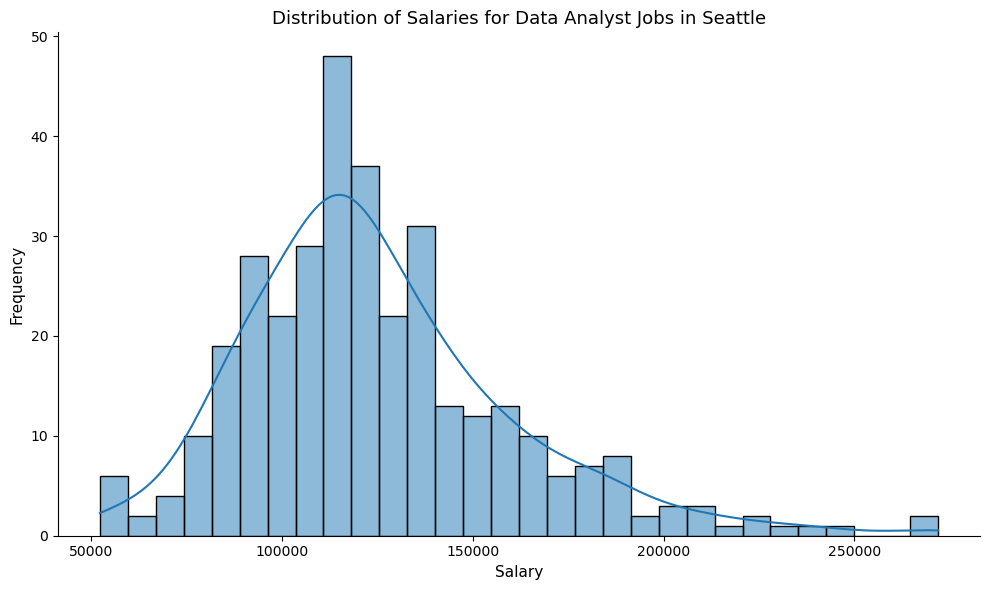

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(jobs_df['Salary'], kde=True, palette='Blues', bins=30)
plt.title('Distribution of Salaries for Data Analyst Jobs in Seattle', fontsize = 13)
plt.xlabel('Salary', fontsize = 11)
plt.ylabel('Frequency', fontsize = 11)
sns.despine()
plt.tight_layout()
plt.show()

### Salary Distribution Histogram

### Description:
A histogram with a KDE (Kernel Density Estimation) curve shows the salary distribution for **Data Analyst** roles in **Seattle**, with salaries ranging from approximately **\$50,000** to over **\$200,000**.

### Insight:
- Most salaries cluster around **\$80,000** to **\$120,000**, indicating a competitive mid-range market for Data Analysts in Seattle.
- The **right skew** of the distribution suggests that high-paying senior roles (over **\$150,000**) are less common.
- This highlights **opportunities for experienced analysts**, as the data suggests that while most positions fall within the middle salary range, there is still a smaller proportion of higher-paying, senior-level roles.

The histogram provides a visual representation of the salary distribution, enabling better understanding of salary trends in the local job market.


C:\Users\phuon\AppData\Local\Temp\ipykernel_33040\1253921197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_locations.index, y=top_locations.values, palette='Blues')


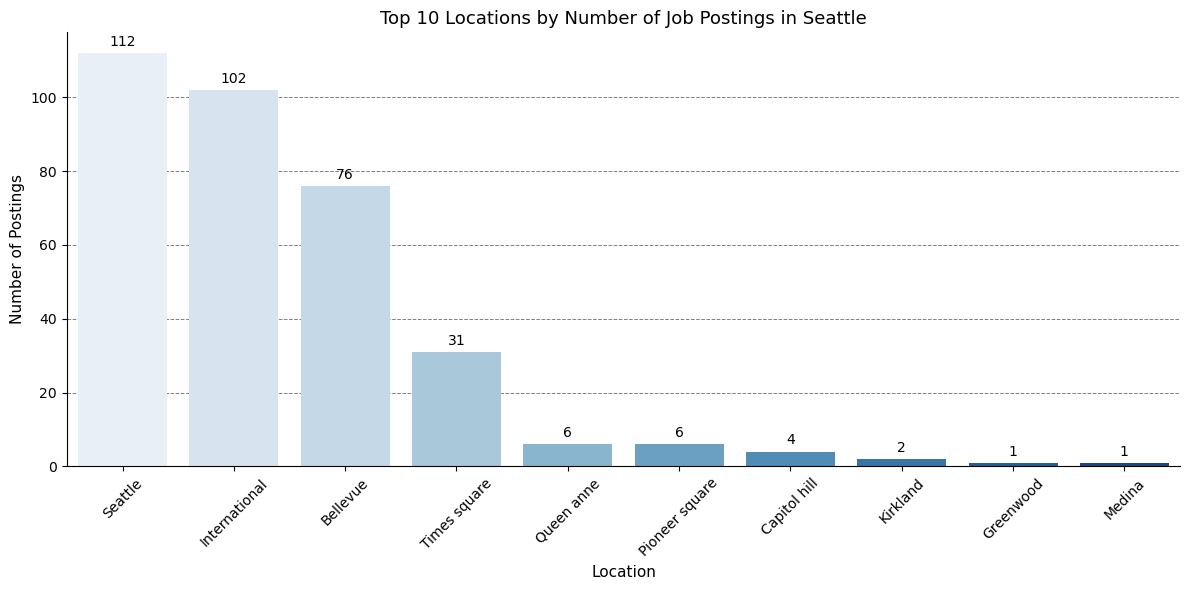

In [40]:
plt.figure(figsize=(12, 6))
top_locations = jobs_df['Location'].value_counts().head(10)

ax = sns.barplot(x=top_locations.index, y=top_locations.values, palette='Blues')
plt.title('Top 10 Locations by Number of Job Postings in Seattle', fontsize = 13)
plt.xlabel('Location', fontsize = 11)
plt.ylabel('Number of Postings', fontsize = 11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3, fontsize=10)

ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, color='gray')
ax.set_axisbelow(True)  

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

### Top 10 Locations by Number of Job Postings in Seattle (Bar Plot)

### Description:
This bar plot illustrates the distribution of job postings across the **top 10 locations in Seattle**. The locations are ranked by the number of job postings. 

### Insight:
- The dominance of **Seattle** and **International** locations suggests a concentration of job opportunities in the urban core.
- **Bellevue's** high count aligns with its reputation as a **tech hub**.
- The **low numbers** in areas like **Medina** and **Greenwood** indicate limited localized demand, with fewer job postings in these neighborhoods compared to more central areas.

The bar plot provides a visual representation of the geographic distribution of job postings, helping to identify where most opportunities are clustered in Seattle.

C:\Users\phuon\AppData\Local\Temp\ipykernel_33040\1078408117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')


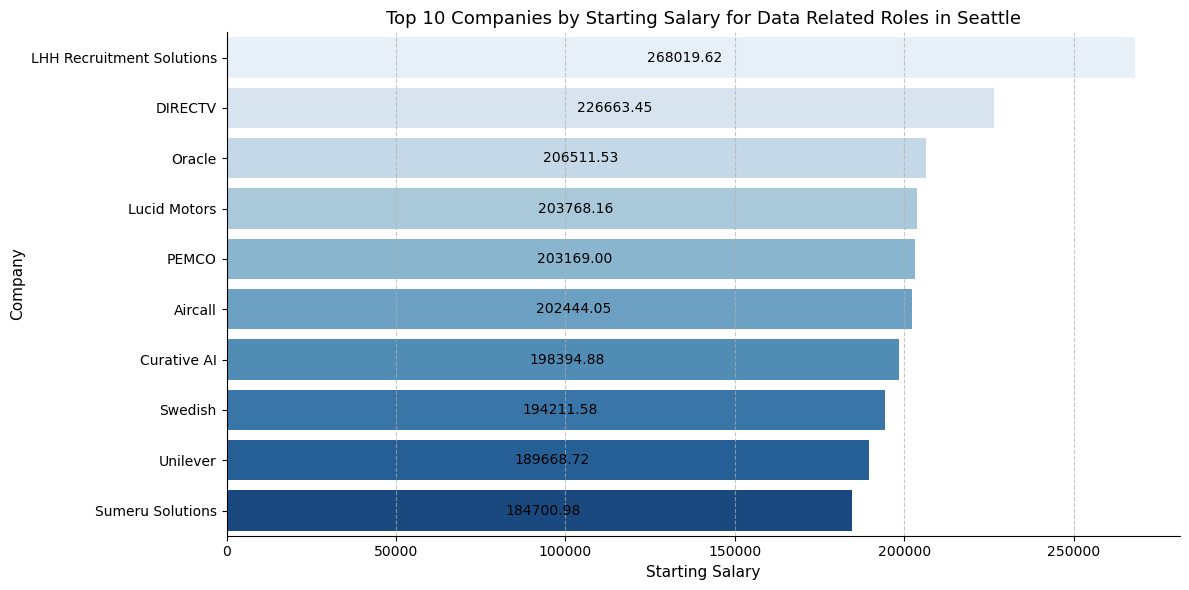

In [27]:
top_companies = jobs_df.groupby('Company')['Salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')
plt.title('Top 10 Companies by Starting Salary for Data Related Roles in Seattle', fontsize = 13)
plt.xlabel('Starting Salary', fontsize = 11)
plt.ylabel('Company', fontsize = 11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='center', padding=3, fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

### Top 10 Companies by Starting Salary for Data-Related Roles in Seattle (Bar Plot)

### Description:
This bar plot ranks the **top 10 companies** offering **data-related roles** in **Seattle** based on **starting salary**. 

### Insight:
- The **wide salary range** suggests significant variation in compensation across companies.
- **Recruitment firms** (like **LHH**) and **tech giants** (such as **Oracle** and **DIRECTV**) offer the highest starting salaries, reflecting their financial capacity and demand for specialized skills.
- Companies like **Sumera Solutions** and **Unilever**, despite having lower starting salaries, still offer competitive pay, suggesting a variety of opportunities across different sectors.
- The salary disparity highlights the importance of **company type** and **role seniority**, suggesting that further analysis of the skill requirements or industry sectors could explain these differences.

The bar plot provides a clear visual comparison of starting salaries across different companies, offering valuable insights into the data-related job market in Seattle.

C:\Users\phuon\AppData\Local\Temp\ipykernel_33040\1892402897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')


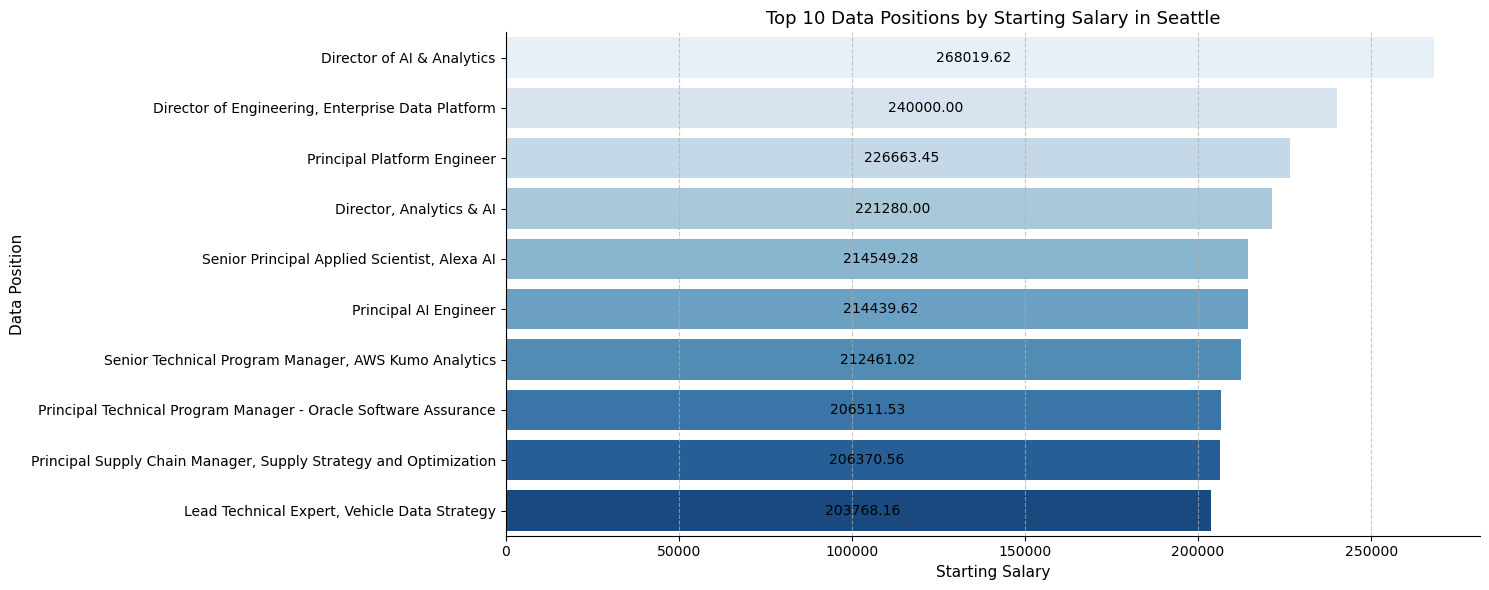

In [36]:
top_companies = jobs_df.groupby('JobTitle')['Salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 6))
ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')
plt.title('Top 10 Data Positions by Starting Salary in Seattle', fontsize = 13)
plt.xlabel('Starting Salary', fontsize = 11)
plt.ylabel('Data Position', fontsize = 11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='center', padding=3, fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

### Top 10 Data Positions by Starting Salary in Seattle (Bar Plot)

### Description:
This bar plot illustrates the starting salaries for the **top 10 data positions** in **Seattle**. The high salaries, especially for **director** and **principal roles** (above \$200,000), reflect a premium for leadership and specialized **AI expertise** in Seattle’s **tech sector**. The presence of **Amazon-related roles** (e.g: **Alexa AI**, **AWS**) underscores their **market dominance**.

### Insight:
- The **high salaries** for senior roles such as **director** and **principal** positions indicate the significant value placed on leadership and advanced technical expertise, particularly in AI.
- **Amazon-related roles**, such as those in **Alexa AI** and **AWS**, reflect the company’s significant influence in Seattle’s tech industry, driving demand for specialized data skills.
- This suggests a growing demand for **advanced skills** in AI, machine learning, and cloud computing, with companies willing to pay a premium for these roles.
- The large salary disparity emphasizes the importance of **experience levels** and **specialized qualifications** in shaping salary offers, prompting further exploration into the qualifications required for these high-paying positions.

The bar plot provides a visual representation of the salary distribution across different data positions, highlighting the premium placed on advanced skills and leadership roles.

C:\Users\phuon\AppData\Local\Temp\ipykernel_33040\692062446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')


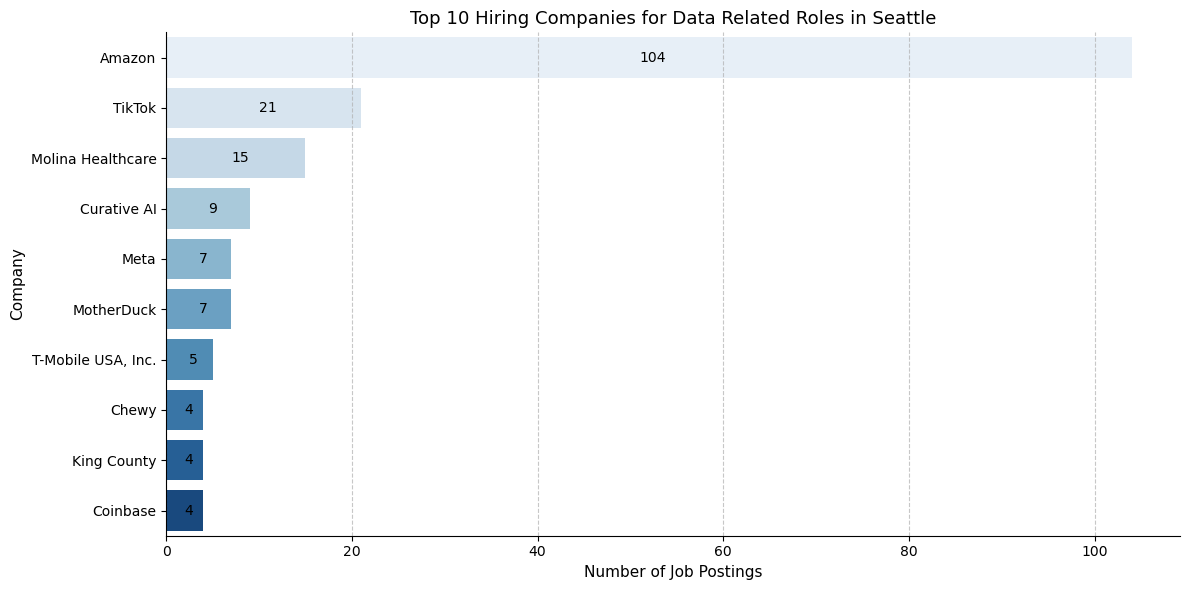

In [29]:
top_companies = jobs_df['Company'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues')
plt.title('Top 10 Hiring Companies for Data Related Roles in Seattle', fontsize = 13)
plt.xlabel('Number of Job Postings', fontsize = 11)
plt.ylabel('Company', fontsize = 11)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center', padding=3, fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

### Top Hiring Companies for Data-Related Roles in Seattle (Bar Plot)

### Description:
This bar plot illustrates the **top hiring companies** for **data-related roles** in **Seattle**. Amazon leads with **104 postings**, reflecting its significant presence in Seattle’s **tech ecosystem**. Other companies like **TikTok** and **Molina Healthcare** show notable hiring activity, indicating involvement from both **tech** and **healthcare** industries. Smaller firms such as **MotherDuck** and **Coinbase** have lower counts, suggesting **niche but growing markets**.

### Insight:
- **Amazon's dominance** with 104 postings underscores its central role in Seattle's tech landscape, making it a major player in the data-related job market.
- The involvement of **TikTok** and **Molina Healthcare** highlights a **diverse job market**, with opportunities spanning not only the tech sector but also healthcare, which is emerging as an important industry for data professionals.
- The lower hiring counts for **smaller firms** like **MotherDuck** and **Coinbase** suggest a **growing but niche market**, where data-related opportunities may be limited but have strong potential for expansion.
- This distribution highlights the **competitive nature of Seattle’s job market**, primarily driven by **tech giants** like Amazon, but with valuable opportunities also arising in **public sectors** (such as **King County**) and **emerging companies**.

This analysis encourages further investigation into **industry trends** and **role diversity**, helping professionals navigate the evolving job market.


## Final steps:
### Reinforcing Conclusions and Next Steps

The data reinforces the conclusion that **Seattle’s job market** for data-related roles is dominated by **tech giants** like **Amazon**, with significant opportunities also emerging in **healthcare** and **smaller, niche companies**. The concentration of job postings around Seattle and International locations further supports the idea of a **centralized job market** in urban hubs.

### Questions Answered through the analysis:
- What companies are driving the job market for data-related roles in Seattle?
- What industries are contributing to the hiring demand?

### Next Steps and Hypothesis:
- **Explore qualifications** required for high-paying roles, particularly in AI and machine learning, to understand what skills are in demand.
- Investigate **salary variations** within different companies and industries to determine how factors like company size, role seniority, and location influence compensation.
- **Hypothesis**: Roles requiring specialized skills in AI or cloud computing will have higher salaries, and demand for these roles will grow as Seattle’s tech sector expands.

In [42]:
#jobs_df.to_csv("seattle_data_analyst_jobs.csv", index=False)